<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/dl_projects/experiment_autoencoder_variants_representation_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==========================================================
# BASIC AUTOENCODER
# ==========================================================

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = 784

# Encoder

input_layer = Input(shape=(input_dim,))

encoded = Dense(
    128,
    activation="relu"
)(input_layer)

latent = Dense(
    32,
    activation="relu"
)(encoded)

# Decoder

decoded = Dense(
    128,
    activation="relu"
)(latent)

output = Dense(
    input_dim,
    activation="sigmoid"
)(decoded)

autoencoder = Model(
    input_layer,
    output
)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# ==========================================================
# DEEP AUTOENCODER
# ==========================================================

encoder = tf.keras.Sequential([

    Dense(512, activation="relu"),

    Dense(256, activation="relu"),

    Dense(128, activation="relu"),

    Dense(64, activation="relu")
])

decoder = tf.keras.Sequential([

    Dense(128, activation="relu"),

    Dense(256, activation="relu"),

    Dense(512, activation="relu"),

    Dense(784, activation="sigmoid")
])

inputs = Input(shape=(784,))

latent = encoder(inputs)

outputs = decoder(latent)

model = Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64)             │       574,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       575,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,149,520 (4.39 MB)

 Trainable params: 1,149,520 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Denoising Autoencoder

In [4]:
import numpy as np
import tensorflow as tf

# Load and preprocess MNIST dataset as an example for x_train
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))

noise_factor = 0.30

x_train_noisy = (
    x_train
    + noise_factor *
    np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_train.shape
    )
)

x_train_noisy = np.clip(
    x_train_noisy,
    0.,
    1.
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

model.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.2262
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1447
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1265
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1170
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1116
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1075
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1045
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1021
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1002
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0986
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0974
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0962
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0952
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0943
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - l

Sparse Autoencoder

In [6]:
from tensorflow.keras import regularizers

latent = Dense(

    32,

    activation="relu",

    activity_regularizer=
    regularizers.l1(1e-5)

)(encoded)

Convolutional Autoencoder

Encoder

In [7]:
encoder_input = Input(
    shape=(128,128,3)
)

x = tf.keras.layers.Conv2D(
    32,
    3,
    activation='relu',
    padding='same'
)(encoder_input)

x = tf.keras.layers.MaxPooling2D(
    2,
    padding='same'
)(x)

x = tf.keras.layers.Conv2D(
    64,
    3,
    activation='relu',
    padding='same'
)(x)

x = tf.keras.layers.MaxPooling2D(
    2,
    padding='same'
)(x)

Decoder

In [8]:
x = tf.keras.layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    activation='relu',
    padding='same'
)(x)

x = tf.keras.layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    activation='relu',
    padding='same'
)(x)

output = tf.keras.layers.Conv2D(
    3,
    3,
    activation='sigmoid',
    padding='same'
)(x)

Variational Autoencoder (VAE)

Sampling Layer

In [9]:
class Sampling(tf.keras.layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]

        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return (
            z_mean
            +
            tf.exp(
                0.5 * z_log_var
            )
            * epsilon
        )

Autoencoder for Anomaly Detection

Reconstruction Error

In [10]:
# Load and preprocess MNIST test data
(_, _), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_test = X_test.astype('float32') / 255.
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

reconstruction = model.predict(
    X_test
)

mse = np.mean(
    np.square(
        X_test -
        reconstruction
    ),
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


Detect Anomalies

In [11]:
threshold = np.percentile(
    mse,
    95
)

anomalies = mse > threshold

Production-Level Autoencoder

Callbacks

In [12]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        factor=0.2,

        patience=3
    ),

    tf.keras.callbacks.ModelCheckpoint(

        "best_autoencoder.keras",

        save_best_only=True
    )
]

Training

In [13]:
from sklearn.model_selection import train_test_split

# Split x_train and x_train_noisy into training and validation sets
x_train_split, x_val_split, x_train_noisy_split, x_val_noisy_split = train_test_split(
    x_train, x_train_noisy, test_size=0.2, random_state=42
)

# Create TensorFlow Dataset objects
batch_size = 256 # Using the same batch_size as in model.fit

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy_split, x_train_split)).batch(batch_size).cache().shuffle(1024)
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_noisy_split, x_val_split)).batch(batch_size).cache()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0897 - val_loss: 0.0902 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0893 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0889 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0883 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0880 - val_loss: 0.0901 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0878 - val_loss: 0.0902 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0874 - val_loss: 0.0906 - learning_rate: 0.0010
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0850 - val_loss: 0.0889 - learning_rate: 2.0000e-04
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0848 - val_loss: 0.0888 - learning_rate: 2.0

Latent Space Visualization

In [14]:
from sklearn.manifold import TSNE

latent_vectors = encoder.predict(
    X_test
)

tsne = TSNE(
    n_components=2
)

latent_2d = tsne.fit_transform(
    latent_vectors
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


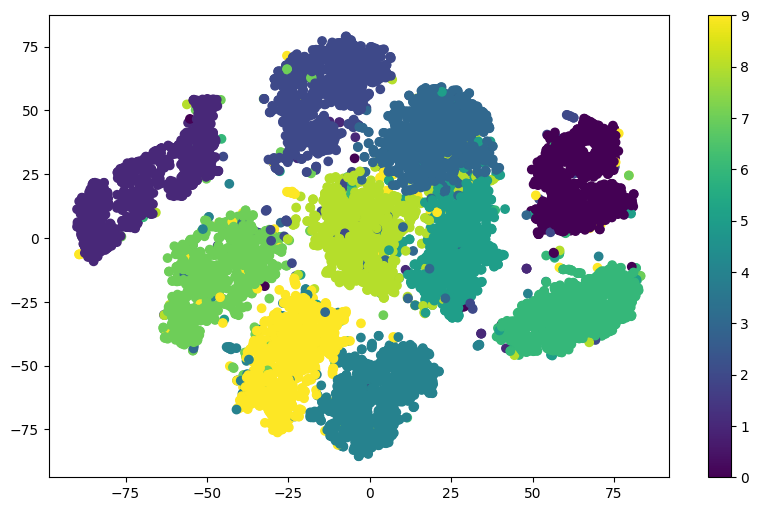

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(

    latent_2d[:,0],

    latent_2d[:,1],

    c=y_test
)

plt.colorbar()

plt.show()